# Brain Tumor MRI Classifier - Training Notebook

Transfer learning with EfficientNet-B0 on the [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset).

**Classes:** glioma, meningioma, no_tumor, pituitary

Run this notebook in Google Colab with a GPU runtime.

## 1. Setup & Download Dataset

In [2]:
# Install kaggle CLI if needed
!pip install -q kaggle

In [3]:
import os

# Paste your Kaggle API token here (from kaggle.com/settings > API)
os.environ["KAGGLE_API_TOKEN"] = "***REMOVED-KAGGLE-TOKEN***"

In [4]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d data

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:02<00:00, 72.9MB/s]



In [9]:
import os

# Check dataset structure
for split in ['Training', 'Testing']:
    print(f"\n{split}:")
    split_dir = os.path.join('data', split)
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            print(f"  {cls}: {len(os.listdir(cls_dir))} images")


Training:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Testing:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


## 2. Data Loading & Augmentation

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [11]:
# ImageNet normalization stats
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder('data/Training', transform=train_transforms)
test_dataset = datasets.ImageFolder('data/Testing', transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

CLASS_NAMES = train_dataset.classes
print(f"Classes: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} images")
print(f"Test: {len(test_dataset)} images")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5600 images
Test: 1600 images


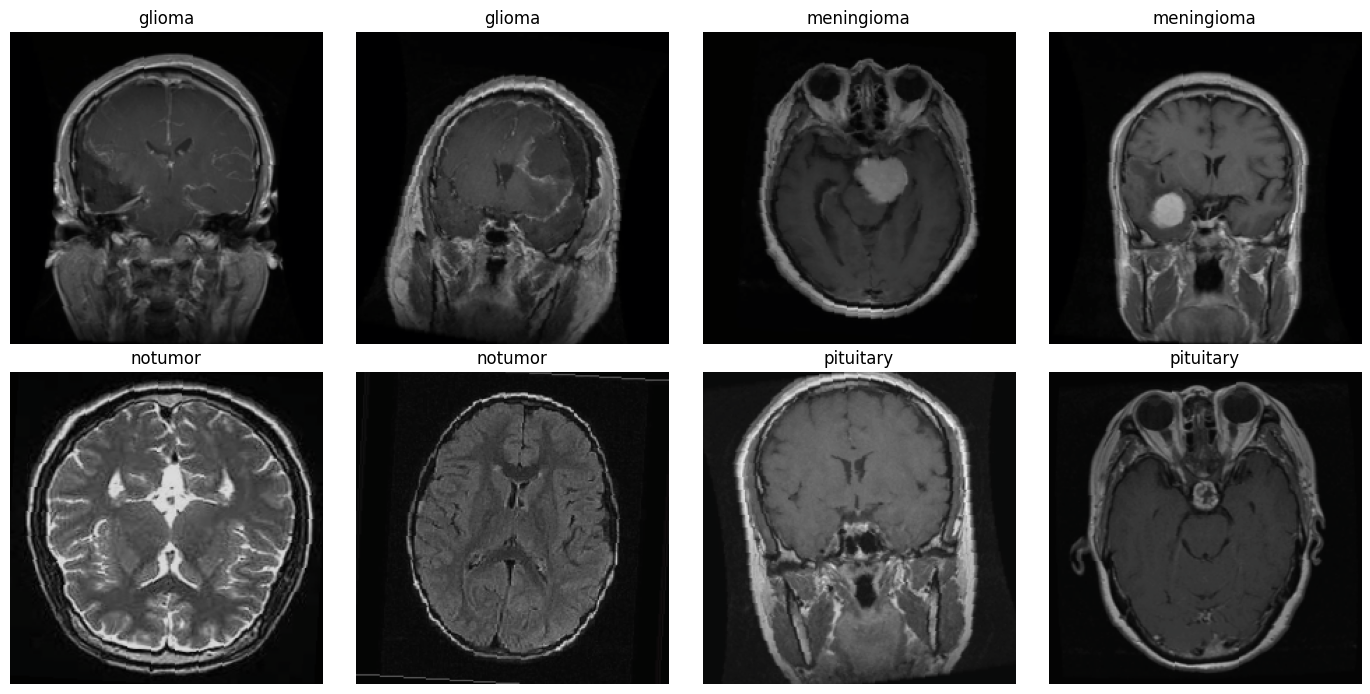

In [7]:
# Visualize some samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i * (len(train_dataset) // 8)]
    # Denormalize for display
    img_display = img.permute(1, 2, 0).numpy()
    img_display = img_display * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Model Setup

In [13]:
# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier head
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(1280, 4),
)

model = model.to(device)

# Count parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]


Trainable parameters: 5,124 / 4,012,672


## 4. Training

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

NUM_EPOCHS = 15
train_losses = []
test_accuracies = []

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)

    # Evaluate
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_acc = 100.0 * correct / total
    test_accuracies.append(test_acc)

    scheduler.step(train_loss)
    lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc:.1f}% | LR: {lr:.6f}")

Epoch 1/15 | Loss: 0.6402 | Train Acc: 78.9% | Test Acc: 79.1% | LR: 0.001000
Epoch 2/15 | Loss: 0.4217 | Train Acc: 85.5% | Test Acc: 80.8% | LR: 0.001000
Epoch 3/15 | Loss: 0.3896 | Train Acc: 86.2% | Test Acc: 82.1% | LR: 0.001000
Epoch 4/15 | Loss: 0.3728 | Train Acc: 86.5% | Test Acc: 82.3% | LR: 0.001000
Epoch 5/15 | Loss: 0.3583 | Train Acc: 87.3% | Test Acc: 83.7% | LR: 0.001000
Epoch 6/15 | Loss: 0.3405 | Train Acc: 88.2% | Test Acc: 83.5% | LR: 0.001000
Epoch 7/15 | Loss: 0.3501 | Train Acc: 87.0% | Test Acc: 84.2% | LR: 0.001000
Epoch 8/15 | Loss: 0.3358 | Train Acc: 87.8% | Test Acc: 84.5% | LR: 0.001000
Epoch 9/15 | Loss: 0.3265 | Train Acc: 87.9% | Test Acc: 84.2% | LR: 0.001000
Epoch 10/15 | Loss: 0.3378 | Train Acc: 87.6% | Test Acc: 84.3% | LR: 0.001000
Epoch 11/15 | Loss: 0.3225 | Train Acc: 88.1% | Test Acc: 84.6% | LR: 0.001000
Epoch 12/15 | Loss: 0.3102 | Train Acc: 88.6% | Test Acc: 85.3% | LR: 0.001000
Epoch 13/15 | Loss: 0.3168 | Train Acc: 87.8% | Test Acc: 85.

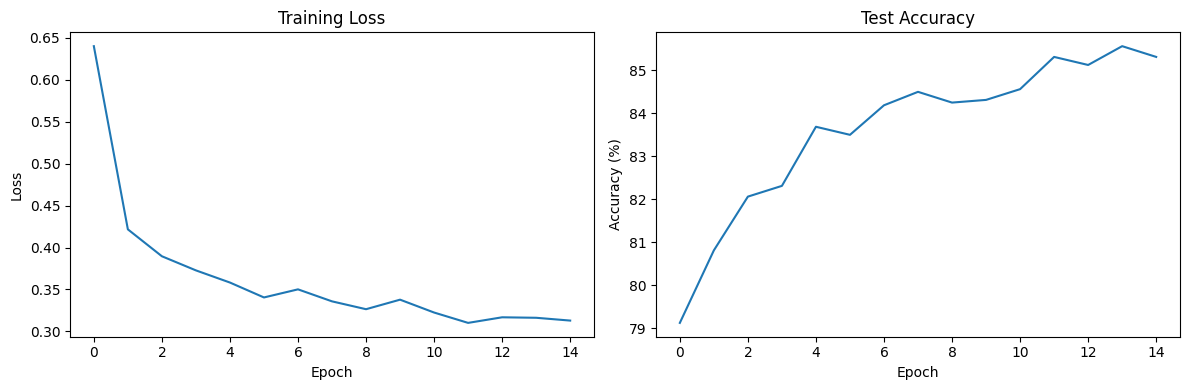


Best test accuracy: 85.6%


In [10]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(test_accuracies)
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

print(f"\nBest test accuracy: {max(test_accuracies):.1f}%")

## 5. Detailed Evaluation

              precision    recall  f1-score   support

      glioma       0.97      0.65      0.78       400
  meningioma       0.78      0.80      0.79       400
     notumor       0.80      0.99      0.89       400
   pituitary       0.91      0.97      0.94       400

    accuracy                           0.85      1600
   macro avg       0.87      0.85      0.85      1600
weighted avg       0.87      0.85      0.85      1600



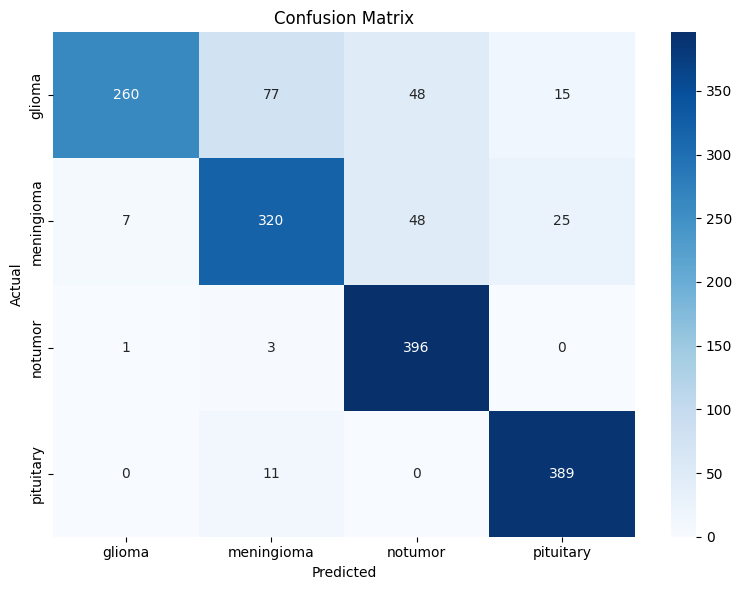

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Export Model

In [12]:
# Save model state dict (CPU)
model_cpu = model.cpu()
torch.save(model_cpu.state_dict(), 'tumor_classifier.pth')

# Check file size
size_mb = os.path.getsize('tumor_classifier.pth') / (1024 * 1024)
print(f"Model saved: tumor_classifier.pth ({size_mb:.1f} MB)")

Model saved: tumor_classifier.pth (15.6 MB)


In [14]:
from google.colab import files
files.download('tumor_classifier.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Also save a few sample images for the frontend demo
import shutil
os.makedirs('sample_mris', exist_ok=True)

for cls in CLASS_NAMES:
    cls_dir = os.path.join('data', 'Testing', cls)
    sample = os.listdir(cls_dir)[0]
    src = os.path.join(cls_dir, sample)
    dst = os.path.join('sample_mris', f'{cls}.jpg')
    shutil.copy2(src, dst)
    print(f"Saved sample: {dst}")

# Zip and download samples
shutil.make_archive('sample_mris', 'zip', '.', 'sample_mris')
files.download('sample_mris.zip')

Saved sample: sample_mris/glioma.jpg
Saved sample: sample_mris/meningioma.jpg
Saved sample: sample_mris/notumor.jpg
Saved sample: sample_mris/pituitary.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Unfreeze last 2 blocks of the backbone
for param in model.features[-2:].parameters():
    param.requires_grad = True

model = model.to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    test_acc = 100.0 * correct / total
    scheduler.step(train_loss)
    lr = optimizer.param_groups[0]['lr']
    print(f"Fine-tune {epoch+1}/10 | Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc:.1f}% | LR: {lr:.6f}")

# Save the improved model
torch.save(model.cpu().state_dict(), 'tumor_classifier.pth')
from google.colab import files
files.download('tumor_classifier.pth')


Fine-tune 1/10 | Loss: 0.2855 | Train Acc: 89.6% | Test Acc: 87.1% | LR: 0.000100
Fine-tune 2/10 | Loss: 0.2401 | Train Acc: 91.2% | Test Acc: 87.8% | LR: 0.000100
Fine-tune 3/10 | Loss: 0.1947 | Train Acc: 92.7% | Test Acc: 89.2% | LR: 0.000100
Fine-tune 4/10 | Loss: 0.1805 | Train Acc: 93.2% | Test Acc: 90.4% | LR: 0.000100
Fine-tune 5/10 | Loss: 0.1506 | Train Acc: 94.5% | Test Acc: 90.7% | LR: 0.000100
Fine-tune 6/10 | Loss: 0.1353 | Train Acc: 94.8% | Test Acc: 91.4% | LR: 0.000100
Fine-tune 7/10 | Loss: 0.1438 | Train Acc: 94.6% | Test Acc: 91.8% | LR: 0.000100
Fine-tune 8/10 | Loss: 0.1237 | Train Acc: 95.6% | Test Acc: 91.6% | LR: 0.000100
Fine-tune 9/10 | Loss: 0.1188 | Train Acc: 95.7% | Test Acc: 92.1% | LR: 0.000100
Fine-tune 10/10 | Loss: 0.1098 | Train Acc: 96.1% | Test Acc: 92.6% | LR: 0.000100


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets

# More aggressive augmentation
train_transforms_v2 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2),
])

train_dataset_v2 = datasets.ImageFolder('data/Training', transform=train_transforms_v2)
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=32, shuffle=True, num_workers=2)

# Unfreeze ENTIRE backbone
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

# Lower learning rate with cosine annealing
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader_v2:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    test_acc = 100.0 * correct / total
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']
    print(f"V2 {epoch+1}/20 | Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc:.1f}% | LR: {lr:.6f}")

torch.save(model.cpu().state_dict(), 'tumor_classifier_v2.pth')
from google.colab import files
files.download('tumor_classifier_v2.pth')


V2 1/20 | Loss: 0.7582 | Train Acc: 75.1% | Test Acc: 81.8% | LR: 0.000050
V2 2/20 | Loss: 0.3254 | Train Acc: 88.8% | Test Acc: 87.4% | LR: 0.000049
V2 3/20 | Loss: 0.2256 | Train Acc: 91.7% | Test Acc: 90.5% | LR: 0.000047
V2 4/20 | Loss: 0.1738 | Train Acc: 93.7% | Test Acc: 90.8% | LR: 0.000045
V2 5/20 | Loss: 0.1495 | Train Acc: 94.7% | Test Acc: 93.3% | LR: 0.000043
V2 6/20 | Loss: 0.1250 | Train Acc: 96.0% | Test Acc: 93.4% | LR: 0.000040
V2 7/20 | Loss: 0.1103 | Train Acc: 96.1% | Test Acc: 93.0% | LR: 0.000036
V2 8/20 | Loss: 0.1086 | Train Acc: 96.2% | Test Acc: 93.5% | LR: 0.000033
V2 9/20 | Loss: 0.0989 | Train Acc: 96.6% | Test Acc: 94.8% | LR: 0.000029
V2 10/20 | Loss: 0.0976 | Train Acc: 96.5% | Test Acc: 94.6% | LR: 0.000025
V2 11/20 | Loss: 0.0850 | Train Acc: 96.8% | Test Acc: 94.6% | LR: 0.000021
V2 12/20 | Loss: 0.0786 | Train Acc: 97.2% | Test Acc: 94.4% | LR: 0.000017
V2 13/20 | Loss: 0.0779 | Train Acc: 97.3% | Test Acc: 95.2% | LR: 0.000014
V2 14/20 | Loss: 0.07

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>